In [ ]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
from src.ingestion import DataIngestor

print("⚙️ Ambiente configurato con successo!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
⚙️ Ambiente configurato con successo!


In [ ]:
START_DATE = "2025-03-01"
END_DATE = "2025-12-31"

ingestor = DataIngestor(start_date=START_DATE, end_date=END_DATE, frequency="W")

print(f"🚀 Ingestor pronto per l'orizzonte temporale: {START_DATE} / {END_DATE}")

🚀 Ingestor pronto per l'orizzonte temporale: 2025-03-01 / 2025-12-31


In [24]:
print("📈 Esecuzione: Recupero dati storici di Mercato...")
df_market = ingestor.fetch_market_data(ticker="BTC-USD")

print(f"\nFormato Tabella: {df_market.shape} (Righe/Settimane, Colonne)")
df_market.head()

[*********************100%***********************]  1 of 1 completed

📈 Esecuzione: Recupero dati storici di Mercato...

Formato Tabella: (45, 5) (Righe/Settimane, Colonne)


Price,Open,High,Low,Close,Volume
timestamp,,,,,
2025-03-02,84373.867188,95043.437500,83794.234375,94248.351562,87588969488
2025-03-09,94248.421875,94429.750000,80052.484375,80601.039062,351467410238
2025-03-16,80597.148438,85263.289062,76624.250000,82579.687500,245099235090
2025-03-23,82576.335938,87443.265625,81179.992188,86054.375000,154637791297
2025-03-30,86070.929688,88758.726562,81573.250000,82334.523438,181637739548


In [25]:
print("⛏️ Esecuzione: Metriche On-Chain (Bitcoin Mining)...")
df_mining = ingestor.fetch_mining_metrics()

print(f"\nFormato Tabella: {df_mining.shape}")
df_mining.head()

⛏️ Esecuzione: Metriche On-Chain (Bitcoin Mining)...

Formato Tabella: (43, 2)


,hash_rate,difficulty
timestamp,,
2025-03-09,7.777387e+08,1.105684e+14
2025-03-16,8.306723e+08,1.121495e+14
2025-03-23,7.916475e+08,1.121495e+14
2025-03-30,8.708571e+08,1.137575e+14
2025-04-06,8.561975e+08,1.150807e+14


In [ ]:
print("🕊️ Esecuzione: Social Feed Ingestion (KaggleHub 2025)...")
df_social = ingestor.fetch_social_feed()

print(f"\nTotale tweet caricati e storicizzati per il 2025: {len(df_social)}")

🕊️ Esecuzione: Social Feed Ingestion (KaggleHub 2025)...
   -> Caricate 4786236 righe da Twitter (2025/2026)
Concatenazione e pulizia dell'archivio globale...
Filtraggio dati per il macro-intervallo richiesto: 2025-03-01 / 2025-12-31...
Ordinamento cronologico dei post...
Scrittura del file finale unificato (4108605 righe)...
Processo completato! Dataset unificato salvato in: ./data/bitcoin_social_dataset_unified.csv

Totale tweet caricati e storicizzati per il 2025: 4108605


In [29]:
print("📊 Statistiche temporali del dataset:")
print(f"Data MINIMA trovata: {df_social['timestamp'].min()}")
print(f"Data MASSIMA trovata: {df_social['timestamp'].max()}")
print(f"Totale righe nel DataFrame: {len(df_social)}")
print(f"Numero di valori nulli (NaT): {df_social['timestamp'].isna().sum()}")

print("\n🔍 Prime 5 righe del dataset:")
print(df_social[['timestamp', 'source']].head())

📊 Statistiche temporali del dataset:
Data MINIMA trovata: 2025-03-06 14:42:53
Data MASSIMA trovata: 2025-12-30 23:59:59
Totale righe nel DataFrame: 4108605
Numero di valori nulli (NaT): 0

🔍 Prime 5 righe del dataset:
            timestamp     source
0 2025-03-06 14:42:53  X_Twitter
1 2025-03-06 14:42:56  X_Twitter
2 2025-03-06 14:42:57  X_Twitter
3 2025-03-06 14:43:00  X_Twitter
4 2025-03-06 14:43:02  X_Twitter


/tmp/ipykernel_17100/271453963.py:49: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


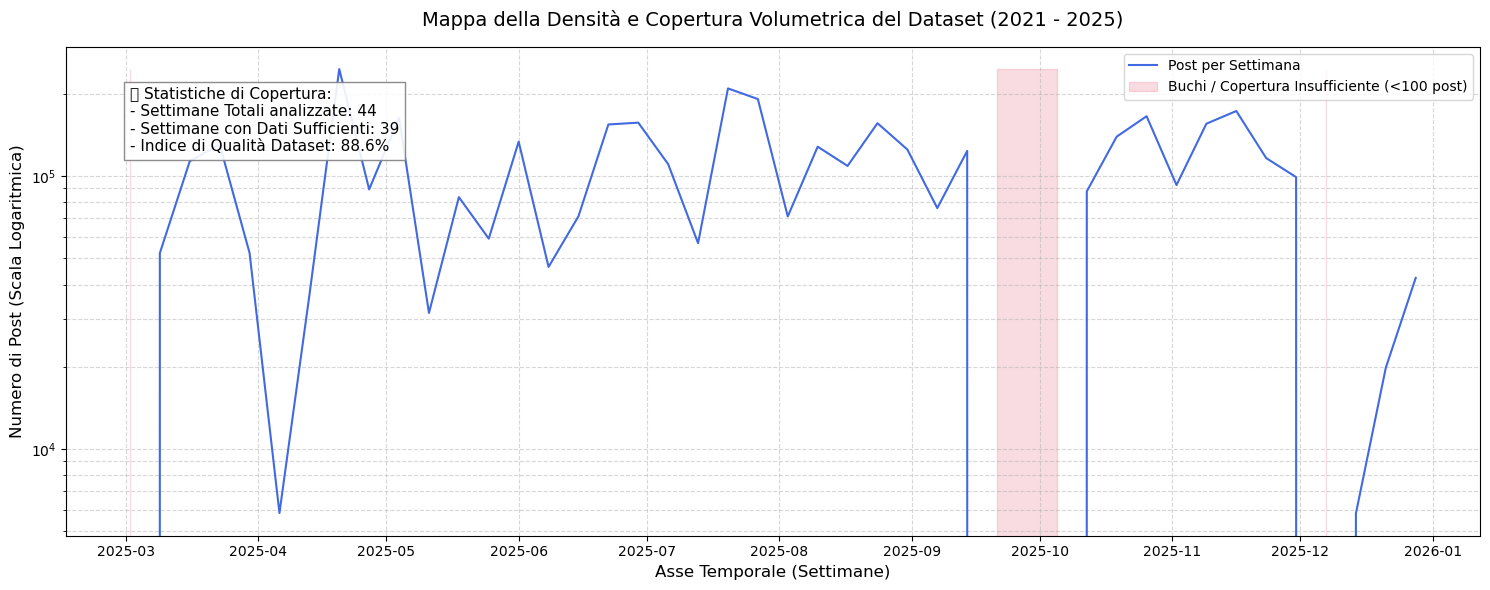

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_social['timestamp'] = pd.to_datetime(df_social['timestamp'])
tutte_le_settimane = pd.date_range(start=ingestor.start_date, end=ingestor.end_date, freq='W')

conteggio_settimanale = df_social.groupby(pd.Grouper(key='timestamp', freq='W')).size()
conteggio_settimanale = conteggio_settimanale.reindex(tutte_le_settimane, fill_value=0)

plt.figure(figsize=(15, 6))

volumi_log = np.log1p(conteggio_settimanale)

plt.plot(tutte_le_settimane, conteggio_settimanale, color='royalblue', linewidth=1.5, label='Post per Settimana')

SOGLIA_MINIMA = 100
buchi = conteggio_settimanale < SOGLIA_MINIMA

plt.fill_between(tutte_le_settimane, 0, conteggio_settimanale.max(), where=buchi,
                 color='crimson', alpha=0.15, label='Buchi / Copertura Insufficiente (<100 post)')

plt.yscale('log')
plt.title("Mappa della Densità e Copertura Volumetrica del Dataset (2021 - 2025)", fontsize=14, pad=15)
plt.xlabel("Asse Temporale (Settimane)", fontsize=12)
plt.ylabel("Numero di Post (Scala Logaritmica)", fontsize=12)
plt.grid(True, which="both", linestyle='--', alpha=0.5)

settimane_totali = len(conteggio_settimanale)
settimane_ok = (conteggio_settimanale >= SOGLIA_MINIMA).sum()
percentuale_qualita = (settimane_ok / settimane_totali) * 100

plt.text(tutte_le_settimane[int(len(tutte_le_settimane)*0.02)], conteggio_settimanale.max() / 2, 
         f"📋 Statistiche di Copertura:\n"
         f"- Settimane Totali analizzate: {settimane_totali}\n"
         f"- Settimane con Dati Sufficienti: {settimane_ok}\n"
         f"- Indice di Qualità Dataset: {percentuale_qualita:.1f}%", 
         fontsize=11, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
print("Stato della directory locale dell'esperimento ('./data'):\n")

file_generati = os.listdir("./data")
for file in file_generati:
    peso_mb = os.path.getsize(f"./data/{file}") / (1024 * 1024)
    print(f"[FILE] {file:<30} | [DIMENSIONE] {peso_mb:.2f} MB")

print("\n🎯 FASE 1 COMPLETATA: L'infrastruttura dati è nativa, locale e persistente!")

📂 Stato della directory locale dell'esperimento ('./data'):

✅ [FILE] btc-usd_market_data.csv        | [DIMENSIONE] 0.00 MB
✅ [FILE] bitcoin_mining_metrics.csv     | [DIMENSIONE] 0.00 MB
✅ [FILE] bitcoin_social_dataset_unified.csv | [DIMENSIONE] 854.21 MB

🎯 FASE 1 COMPLETATA: L'infrastruttura dati è nativa, locale e persistente!
